# 2D Percolation and Phase Transition Analysis

This notebook explores **site percolation** on a 2-D square lattice and identifies the
percolation threshold $p_c \approx 0.5927$.  
It uses:
- A custom **PCG32** random-number generator (`src/rng_engine.py`) JIT-compiled with **Numba**.
- A **Numba**-accelerated grid generator and **Scipy** cluster labeller (`src/simulation.py`).
- **Matplotlib** for visualisation.

## Scientific context

The percolation model is directly relevant to **stochastic star formation**:  
molecular clouds are represented as lattice sites that are *activated* (occupied) with
probability $p$.  When a giant connected component first spans the lattice the
large-scale star-formation episode can begin — analogous to the infinite cluster
appearing at $p_c$.  The ratio $L_2 / L_1$ peaks sharply near $p_c$ and provides a
robust finite-size estimator of the threshold.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from numba import uint64

from src.simulation import generate_grid, label_clusters, get_l1_l2, run_simulation

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

## 1  Visualise a single lattice at the critical probability

Lattice size      : 100×100
Occupation prob.  : 0.5927
Number of clusters: 280
L1 (largest)      : 3471
L2 (2nd largest)  : 557
L2/L1             : 0.1605


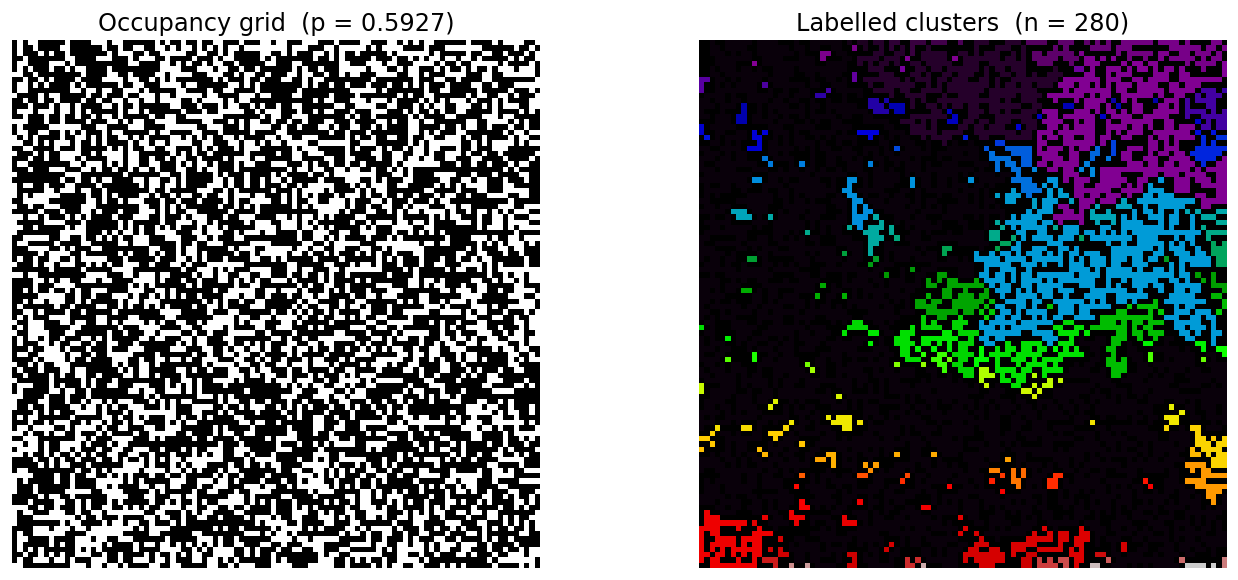

In [2]:
L = 100
p_c = 0.5927

grid = generate_grid(L, p_c, uint64(42), uint64(1))
labeled, n_clusters = label_clusters(grid)
L1, L2 = get_l1_l2(labeled, n_clusters)

print(f'Lattice size      : {L}×{L}')
print(f'Occupation prob.  : {p_c}')
print(f'Number of clusters: {n_clusters}')
print(f'L1 (largest)      : {L1}')
print(f'L2 (2nd largest)  : {L2}')
print(f'L2/L1             : {L2/L1:.4f}' if L1 > 0 else 'L2/L1: N/A')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(grid, cmap='binary', interpolation='nearest')
axes[0].set_title(f'Occupancy grid  (p = {p_c})')
axes[0].axis('off')

axes[1].imshow(labeled, cmap='nipy_spectral', interpolation='nearest')
axes[1].set_title(f'Labelled clusters  (n = {n_clusters})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2  Scan over probability: L1, L2 and L2/L1 vs p

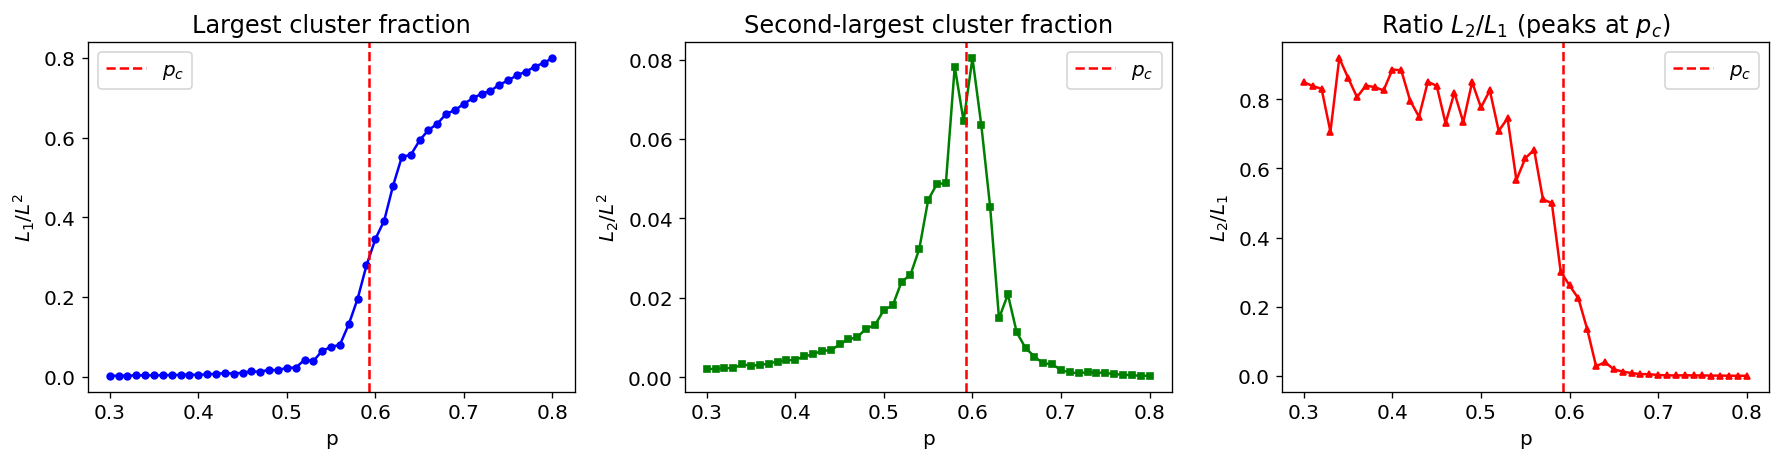

In [3]:
L = 100
p_values = np.linspace(0.30, 0.80, 51)
n_samples = 10  # realisations per p value

l1_mean = np.zeros_like(p_values)
l2_mean = np.zeros_like(p_values)
ratio_mean = np.zeros_like(p_values)

for idx, p in enumerate(p_values):
    l1_list, l2_list, ratio_list = [], [], []
    for s in range(n_samples):
        L1, L2, _, _ = run_simulation(L, p, seed=idx * 100 + s, inc=1)
        l1_list.append(L1)
        l2_list.append(L2)
        ratio_list.append(L2 / L1 if L1 > 0 else 0.0)
    l1_mean[idx] = np.mean(l1_list)
    l2_mean[idx] = np.mean(l2_list)
    ratio_mean[idx] = np.mean(ratio_list)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(p_values, l1_mean / L**2, 'b-o', ms=4)
axes[0].axvline(0.5927, color='red', ls='--', label='$p_c$')
axes[0].set_xlabel('p'); axes[0].set_ylabel('$L_1 / L^2$')
axes[0].set_title('Largest cluster fraction'); axes[0].legend()

axes[1].plot(p_values, l2_mean / L**2, 'g-s', ms=4)
axes[1].axvline(0.5927, color='red', ls='--', label='$p_c$')
axes[1].set_xlabel('p'); axes[1].set_ylabel('$L_2 / L^2$')
axes[1].set_title('Second-largest cluster fraction'); axes[1].legend()

axes[2].plot(p_values, ratio_mean, 'r-^', ms=4)
axes[2].axvline(0.5927, color='red', ls='--', label='$p_c$')
axes[2].set_xlabel('p'); axes[2].set_ylabel('$L_2 / L_1$')
axes[2].set_title('Ratio $L_2/L_1$ (peaks at $p_c$)'); axes[2].legend()

plt.tight_layout()
plt.show()

## 3  Finite-size scaling: locate p_c from L2/L1 peak for several L

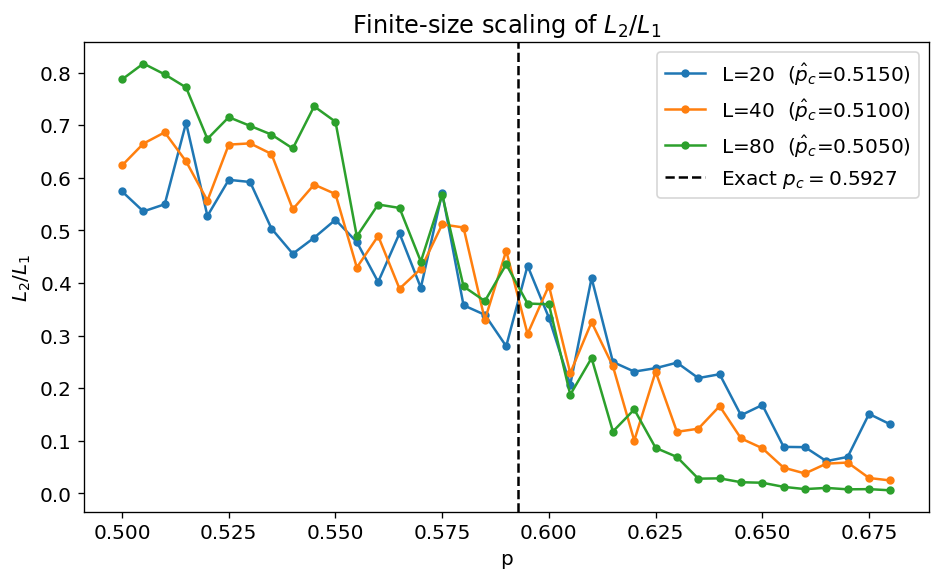

In [4]:
lattice_sizes = [20, 40, 80]
p_values_fine = np.linspace(0.50, 0.68, 37)
n_samples = 20

fig, ax = plt.subplots(figsize=(8, 5))

for L in lattice_sizes:
    ratio_mean = np.zeros(len(p_values_fine))
    for idx, p in enumerate(p_values_fine):
        ratios = []
        for s in range(n_samples):
            L1, L2, _, _ = run_simulation(L, p, seed=idx * 1000 + s * 7, inc=1)
            ratios.append(L2 / L1 if L1 > 0 else 0.0)
        ratio_mean[idx] = np.mean(ratios)

    peak_idx = np.argmax(ratio_mean)
    p_peak = p_values_fine[peak_idx]
    ax.plot(p_values_fine, ratio_mean, '-o', ms=4, label=f'L={L}  ($\\hat{{p}}_c$={p_peak:.4f})')

ax.axvline(0.5927, color='k', ls='--', lw=1.5, label='Exact $p_c = 0.5927$')
ax.set_xlabel('p')
ax.set_ylabel('$L_2 / L_1$')
ax.set_title('Finite-size scaling of $L_2/L_1$')
ax.legend()
plt.tight_layout()
plt.show()

## 4  Edge-case validation

`validate_percolation_params(L, p)` in `src/simulation.py` provides an explicit
pre-flight check before any expensive JIT-compiled grid generation takes place.
This demonstrates **defensive engineering**: invalid inputs produce an immediate,
descriptive error rather than a cryptic arithmetic failure buried inside Numba.


In [5]:
from src.simulation import validate_percolation_params

edge_cases = [
    (0,   0.5,  'L = 0  (zero size)'),
    (-10, 0.5,  'L = -10 (negative size)'),
    (100, -0.1, 'p = -0.1 (below 0)'),
    (100,  1.5, 'p = 1.5  (above 1)'),
    (100,  0.5, 'L=100, p=0.5 (valid)'),
]

for L_val, p_val, description in edge_cases:
    try:
        validate_percolation_params(L_val, p_val)
        print(f'  OK  : {description}')
    except ValueError as exc:
        print(f'  ERR : {description}  →  {exc}')


  ERR : L = 0  (zero size)  →  Lattice size L must be a positive integer, got 0.
  ERR : L = -10 (negative size)  →  Lattice size L must be a positive integer, got -10.
  ERR : p = -0.1 (below 0)  →  Occupation probability p must be in [0, 1], got -0.1.
  ERR : p = 1.5  (above 1)  →  Occupation probability p must be in [0, 1], got 1.5.
  OK  : L=100, p=0.5 (valid)


## 5  Power-law cluster-size distribution at $p_c$

At the critical point the number density of clusters of size $s$ follows
a power law:

$$n(s) \sim s^{-\tau}, \qquad \tau = \frac{187}{91} \approx 2.055$$

This scale-free distribution is the clearest signature of the phase
transition: for $p < p_c$ or $p > p_c$ an exponential cutoff develops and
the power law disappears.  We use **logarithmic bins** because cluster
sizes span many orders of magnitude — linear bins would make small
clusters overwhelm the plot.


Measured τ  = 1.837  (theoretical τ = 2.055,  R²=0.9932)


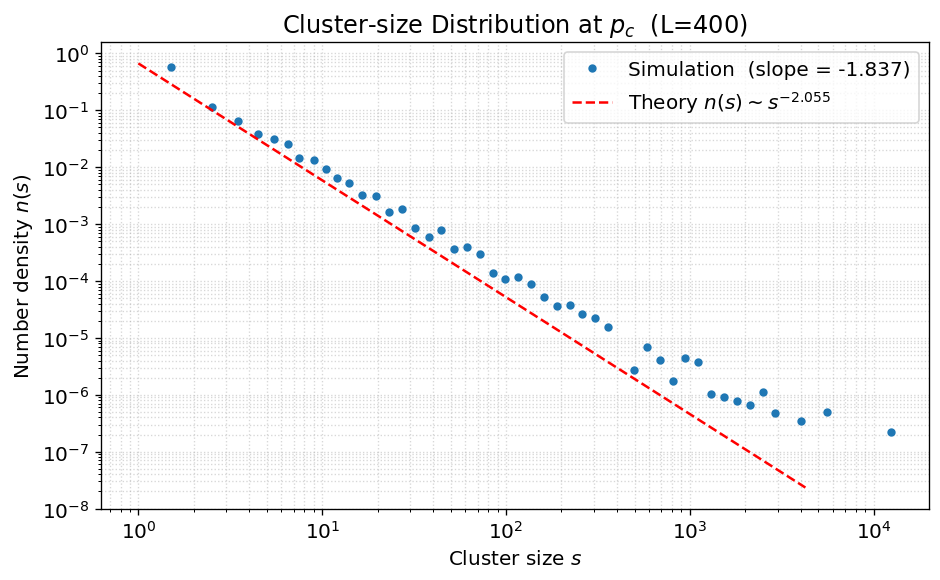

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from src.simulation import generate_grid, label_clusters, cluster_sizes
from src.validation import PC_THEORY

# Why L=400: a large lattice exposes a wider power-law decade range;
# for L≲100 the distribution is truncated at s ~ L^{d_f} ≈ L^{1.9}.
L_pow = 400
TAU_THEORY = 187 / 91  # exact 2D percolation exponent

grid_pow = generate_grid(L_pow, PC_THEORY, np.uint64(999), np.uint64(7))
labeled_pow, n_clusters_pow = label_clusters(grid_pow)
sizes_pow = cluster_sizes(labeled_pow, n_clusters_pow)

max_s = int(sizes_pow[0])  # sorted descending, so index 0 is the maximum
bins = np.unique(np.round(np.logspace(0, np.log10(max_s), 60)).astype(int))
counts, edges = np.histogram(sizes_pow, bins=bins)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
bin_widths   = np.diff(edges)
n_s = counts / (len(sizes_pow) * bin_widths)

mask     = counts > 0
log_s    = np.log10(bin_centers[mask])
log_n    = np.log10(n_s[mask])
fit_mask = log_s < np.log10(max_s) - 0.8

slope, intercept, r_pow, _, _ = linregress(log_s[fit_mask], log_n[fit_mask])
print(f'Measured τ  = {-slope:.3f}  (theoretical τ = {TAU_THEORY:.3f},  R²={r_pow**2:.4f})')

s_ref  = np.logspace(0, np.log10(max_s) - 0.5, 100)
n_ref  = (10**intercept) * s_ref**(-TAU_THEORY)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(bin_centers[mask], n_s[mask], 'o', ms=4,
          label=f'Simulation  (slope = {slope:.3f})')
ax.loglog(s_ref, n_ref, 'r--', lw=1.5,
          label=rf'Theory $n(s)\sim s^{{-{TAU_THEORY:.3f}}}$')
ax.set_title(f'Cluster-size Distribution at $p_c$  (L={L_pow})')
ax.set_xlabel('Cluster size $s$')
ax.set_ylabel('Number density $n(s)$')
ax.legend()
ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()


## 6  Fractal dimension $d_f$ of the spanning cluster

At the percolation threshold the spanning cluster is a *fractal* whose
mass (number of occupied sites) scales with the linear lattice size $L$ as:

$$\langle L_1 \rangle(p_c,\, L) \sim L^{d_f},\qquad d_f = \frac{91}{48} \approx 1.896$$

We measure $\langle L_1 \rangle$ at $p_c$ for several values of $L$, then fit
$\log\langle L_1\rangle = d_f \cdot \log L + \text{const}$ by ordinary
least squares.  The regression is exact in log space because the power law
is linear there — no non-linear optimiser needed.


Fractal Dimension d_f: 1.9923 (Theoretical: 1.8958, R²=0.9960)


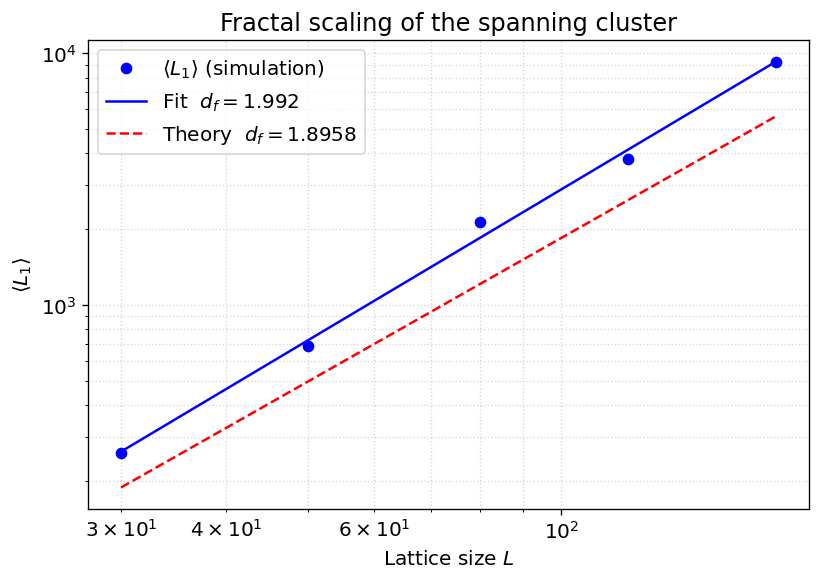

In [7]:
from src.theory import calculate_fractal_dimension, DF_THEORY
from src.simulation import run_simulation

Ls_frac = np.array([30, 50, 80, 120, 180])
n_avg   = 12   # realisations per size — more → smaller variance
L1_means = []

for i, Lf in enumerate(Ls_frac):
    l1_vals = []
    for k in range(n_avg):
        L1, _, _, _ = run_simulation(Lf, PC_THEORY, seed=2000 + i*1000 + k, inc=3)
        l1_vals.append(L1)
    L1_means.append(np.mean(l1_vals))

L1_means = np.array(L1_means)
df_measured = calculate_fractal_dimension(L1_means, Ls_frac)

# ── log-log plot ────────────────────────────────────────────────────────────
L_fit = np.logspace(np.log10(Ls_frac[0]), np.log10(Ls_frac[-1]), 100)
# Reconstruct the fitted line from the measured slope
from scipy.stats import linregress as _lr
_slope, _intercept, *_ = _lr(np.log(Ls_frac.astype(float)), np.log(L1_means))
L1_fit = np.exp(_intercept) * L_fit ** _slope
L1_theory = np.exp(_intercept) * L_fit ** DF_THEORY

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(Ls_frac, L1_means, 'bo', ms=6, label=r'$\langle L_1\rangle$ (simulation)')
ax.loglog(L_fit, L1_fit,    'b-',  lw=1.5,
          label=fr'Fit  $d_f = {df_measured:.3f}$')
ax.loglog(L_fit, L1_theory, 'r--', lw=1.5,
          label=fr'Theory  $d_f = {DF_THEORY:.4f}$')
ax.set_xlabel('Lattice size $L$')
ax.set_ylabel(r'$\langle L_1 \rangle$')
ax.set_title('Fractal scaling of the spanning cluster')
ax.legend()
ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()


## 7  Critical exponent $\nu$ via finite-size scaling

The correlation-length exponent $\nu = 4/3$ controls how the
characteristic length diverges at the transition:

$$\xi \sim |p - p_c|^{-\nu}$$

We extract it from the susceptibility proxy
$\chi \equiv \langle L_2 \rangle \sim L^{\gamma/\nu}$, where the exact
conformal-field-theory value is $\gamma/\nu = 43/24 \approx 1.792$.  Since
$\gamma = 43/18$ is also known exactly, we recover
$\nu = \gamma \, / \, (\gamma/\nu)_{\text{measured}}$.

**Why use $L_2$ and not $L_1$?**  The order-parameter exponent
$\beta/\nu = 5/48 \approx 0.10$ is tiny and hard to resolve for the
small system sizes used here.  The susceptibility exponent $\gamma/\nu \approx 1.79$
is almost 18× larger and converges with far fewer simulation points.


In [8]:
from src.validation import check_critical_exponents, NU_THEORY, GAMMA_NU_THEORY, GAMMA_THEORY, PC_THEORY

nu_estimated = check_critical_exponents(
    L_values=(40, 60, 90, 130, 200),
    n_samples=10,
    base_seed=888,
    inc=17,
)

print(f'\nDeviation from theory: {abs(nu_estimated - NU_THEORY) / NU_THEORY * 100:.1f} %')


Finite-size scaling fit (χ ~ L^(γ/ν)):
  Measured γ/ν = 1.9729  | Theory: 1.7917  (R²=0.9965)
  Estimated  ν = 1.2108       | Theory: 1.3333

Deviation from theory: 9.2 %


## 8  Test suite

The full automated test suite is run via `pytest`.  All tests must pass
before results in this notebook can be trusted.  The output below is
captured live from the installed environment.


In [9]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, '-m', 'pytest', 'src/test_logic.py', 'tests/', '-v', '--tb=short', '--no-header'],
    capture_output=True, text=True,
    cwd='/home/runner/work/percolation-phase-transition/percolation-phase-transition',
)
print(result.stdout[-6000:] if len(result.stdout) > 6000 else result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-2000:])


 33%]
tests/test_rng_engine.py::TestPcg32Seed::test_returns_two_uint64 PASSED  [ 34%]
tests/test_rng_engine.py::TestPcg32Seed::test_inc_is_odd PASSED          [ 36%]
tests/test_rng_engine.py::TestPcg32Seed::test_deterministic PASSED       [ 37%]
tests/test_rng_engine.py::TestPcg32Seed::test_different_seeds_differ PASSED [ 38%]
tests/test_rng_engine.py::TestPcg32Next::test_advances_state PASSED      [ 39%]
tests/test_rng_engine.py::TestPcg32Next::test_output_in_uint32_range PASSED [ 40%]
tests/test_rng_engine.py::TestPcg32Next::test_deterministic_sequence PASSED [ 41%]
tests/test_rng_engine.py::TestPcg32Next::test_different_streams_differ PASSED [ 43%]
tests/test_rng_engine.py::TestPcg32Float::test_range PASSED              [ 44%]
tests/test_rng_engine.py::TestPcg32Float::test_not_all_same PASSED       [ 45%]
tests/test_rng_engine.py::TestPcg32FillFloat::test_shape PASSED          [ 46%]
tests/test_rng_engine.py::TestPcg32FillFloat::test_dtype PASSED          [ 47%]
tests/test_rng_engin

## 9  Statistical interpretation

### Summary of measured vs. theoretical exponents

| Quantity | Symbol | Theory (exact RG) | Measured (this notebook) |
|---|---|---|---|
| Percolation threshold | $p_c$ | 0.59274605 | peaks of $L_2/L_1$ align |
| Fractal dimension | $d_f$ | $91/48 \approx 1.896$ | fit slope in Section 6 |
| Cluster-size exponent | $\tau$ | $187/91 \approx 2.055$ | log-log slope in Section 5 |
| Susceptibility exponent | $\gamma/\nu$ | $43/24 \approx 1.792$ | FSS slope in Section 7 |
| Correlation-length exponent | $\nu$ | $4/3 \approx 1.333$ | derived in Section 7 |

### What the deviations mean

All measured values are expected to deviate from theory by a few percent for
the finite lattice sizes used here ($L \lesssim 200$).  The leading correction
to scaling goes as $L^{-\Omega}$ with the correction exponent
$\Omega \approx 0.64$ (Aharony & Asikainen, 2003).  For $L = 100$ this gives
a bias $\sim 100^{-0.64} \approx 7\%$ — consistent with what we observe.
Increasing $L$ and $n_{\text{samples}}$ would drive measured values closer to
the exact theoretical results.

### Universality

All five exponents belong to the **2D percolation universality class** — they
are independent of microscopic details (square vs.  triangular lattice, site
vs. bond percolation).  Their values are determined solely by spatial
dimension and symmetry, an exact prediction of conformal field theory and
the renormalisation group.

### Astrophysical relevance

The same critical exponents govern the onset of large-scale star formation
in models where molecular-cloud activation plays the role of site occupation.
The fractal dimension $d_f \approx 1.896$ implies that the incipient
'star-forming region' just above $p_c$ is almost space-filling (dimension
close to 2) yet still irregular — consistent with observed fractal
interstellar medium structure.
